In [3]:
import pandas as pd
import numpy as np

import nltk
import re

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud


from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

### Downloading NLP Resources

In [6]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/illapanivarshini/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/illapanivarshini/nltk_data...


True

### Loading Neflix Dataset

In [9]:
df = pd.read_csv("netflix_titles.csv")


df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


### Data Cleaning

In [14]:
df = df[
    [
        "title",
        "description"
    ]
]


df.dropna(inplace=True)


df.head()

,title,description
0,Dick Johnson Is Dead,"As her father nears the end of his life, filmm..."
1,Blood & Water,"After crossing paths at a party, a Cape Town t..."
2,Ganglands,To protect his family from a powerful drug lor...
3,Jailbirds New Orleans,"Feuds, flirtations and toilet talk go down amo..."
4,Kota Factory,In a city of coaching centers known to train I...


### Text Preprocessing

In [17]:
stop_words = set(
    stopwords.words("english")
)


lemmatizer = WordNetLemmatizer()



def clean_text(text):

    # lowercase

    text = text.lower()


    # remove special characters

    text = re.sub(
        "[^a-zA-Z]",
        " ",
        text
    )


    # tokenize

    words = text.split()



    # remove stopwords

    words = [

        word

        for word in words

        if word not in stop_words

    ]



    # lemmatization

    words = [

        lemmatizer.lemmatize(word)

        for word in words

    ]



    return " ".join(words)



df["clean_description"] = (

    df["description"]

    .apply(clean_text)

)


df.head()

,title,description,clean_description
0,Dick Johnson Is Dead,"As her father nears the end of his life, filmm...",father nears end life filmmaker kirsten johnso...
1,Blood & Water,"After crossing paths at a party, a Cape Town t...",crossing path party cape town teen set prove w...
2,Ganglands,To protect his family from a powerful drug lor...,protect family powerful drug lord skilled thie...
3,Jailbirds New Orleans,"Feuds, flirtations and toilet talk go down amo...",feud flirtation toilet talk go among incarcera...
4,Kota Factory,In a city of coaching centers known to train I...,city coaching center known train india finest ...


### Creating Sentiement Labels

In [20]:
positive_words = [

    "love",
    "great",
    "best",
    "amazing",
    "wonderful",
    "fun",
    "success"

]


negative_words = [

    "death",
    "dark",
    "crime",
    "danger",
    "war",
    "killer"

]



def sentiment(text):

    score = 0


    for word in positive_words:

        if word in text:

            score += 1



    for word in negative_words:

        if word in text:

            score -= 1



    if score >= 0:

        return "Positive"

    else:

        return "Negative"



df["sentiment"] = (

    df["clean_description"]

    .apply(sentiment)

)


df.head()

,title,description,clean_description,sentiment
0,Dick Johnson Is Dead,"As her father nears the end of his life, filmm...",father nears end life filmmaker kirsten johnso...,Negative
1,Blood & Water,"After crossing paths at a party, a Cape Town t...",crossing path party cape town teen set prove w...,Positive
2,Ganglands,To protect his family from a powerful drug lor...,protect family powerful drug lord skilled thie...,Negative
3,Jailbirds New Orleans,"Feuds, flirtations and toilet talk go down amo...",feud flirtation toilet talk go among incarcera...,Positive
4,Kota Factory,In a city of coaching centers known to train I...,city coaching center known train india finest ...,Positive


### Sentiment Distribution

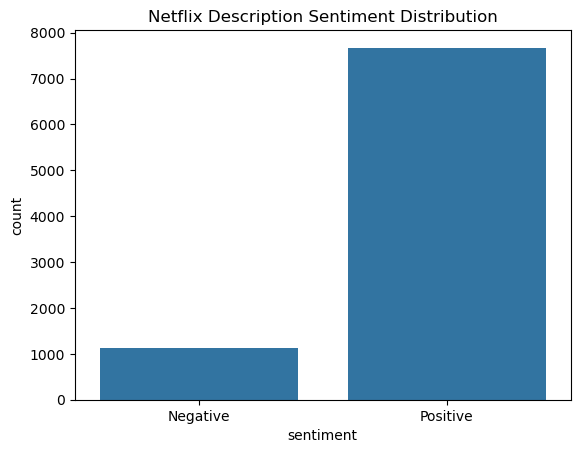

In [23]:
sns.countplot(
    x="sentiment",
    data=df
)


plt.title(
    "Netflix Description Sentiment Distribution"
)


plt.show()

### Feature Extraction

In [26]:
tfidf = TfidfVectorizer(
    max_features=5000
)



X = tfidf.fit_transform(

    df["clean_description"]

)



y = df["sentiment"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

### Model Training

In [31]:
model = LogisticRegression()


model.fit(

    X_train,

    y_train

)

LogisticRegression()

### Prediction

In [34]:
y_pred = model.predict(

    X_test

)

### Evaluation

In [37]:
accuracy = accuracy_score(

    y_test,

    y_pred

)


accuracy

0.9154370034052214

### Classification Report

In [40]:
print(

classification_report(

    y_test,

    y_pred

)

)

              precision    recall  f1-score   support

    Negative       0.98      0.37      0.54       235
    Positive       0.91      1.00      0.95      1527

    accuracy                           0.92      1762
   macro avg       0.94      0.69      0.75      1762
weighted avg       0.92      0.92      0.90      1762



### Confusion Matrix

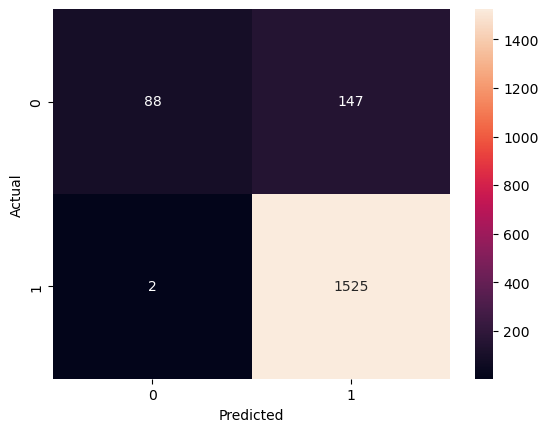

In [43]:
cm = confusion_matrix(

    y_test,

    y_pred

)


sns.heatmap(

    cm,

    annot=True,

    fmt="d"

)


plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

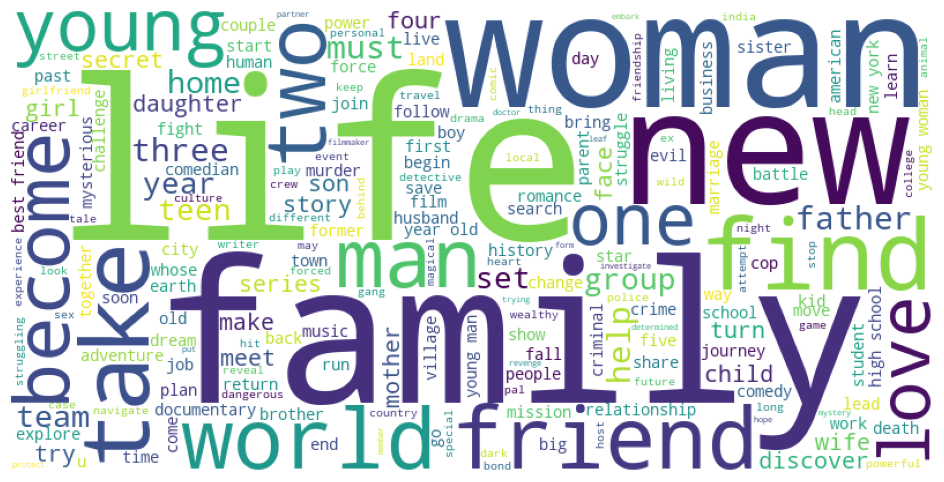

In [45]:
text = " ".join(

    df["clean_description"]

)



wordcloud = WordCloud(

    width=800,

    height=400,

    background_color="white"

).generate(text)



plt.figure(figsize=(12,6))


plt.imshow(

    wordcloud

)


plt.axis("off")


plt.show()